<a href="https://colab.research.google.com/github/emanameen9982773/Crime-Type-Classification-Based-on-Incident-Features/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/emanameen9982773/Crime-Type-Classification-Based-on-Incident-Features.git

Cloning into 'Crime-Type-Classification-Based-on-Incident-Features'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 23 (delta 4), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 14.51 KiB | 2.90 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [3]:
!ls Crime-Type-Classification-Based-on-Incident-Features #cheaking if dataset exist

CSC463_models.ipynb  dataset.csv  model.ipynb  README.md


In [69]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
dataset = pd.read_csv("/content/Crime-Type-Classification-Based-on-Incident-Features/dataset.csv",
                      nrows=500000,
                      on_bad_lines='skip',
                      low_memory=False)
print(dataset.info())
print(dataset.describe(include='all')) # to visualize the info and understand our dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    500000 non-null  int64  
 1   Case Number           500000 non-null  object 
 2   Date                  500000 non-null  object 
 3   Block                 500000 non-null  object 
 4   IUCR                  500000 non-null  object 
 5   Primary Type          500000 non-null  object 
 6   Description           500000 non-null  object 
 7   Location Description  500000 non-null  object 
 8   Arrest                500000 non-null  bool   
 9   Domestic              500000 non-null  bool   
 10  Beat                  500000 non-null  int64  
 11  District              500000 non-null  float64
 12  Ward                  500000 non-null  float64
 13  Community Area        500000 non-null  float64
 14  FBI Code              500000 non-null  object 
 15  

### Now we want to visulaze our data for better understanding of it and

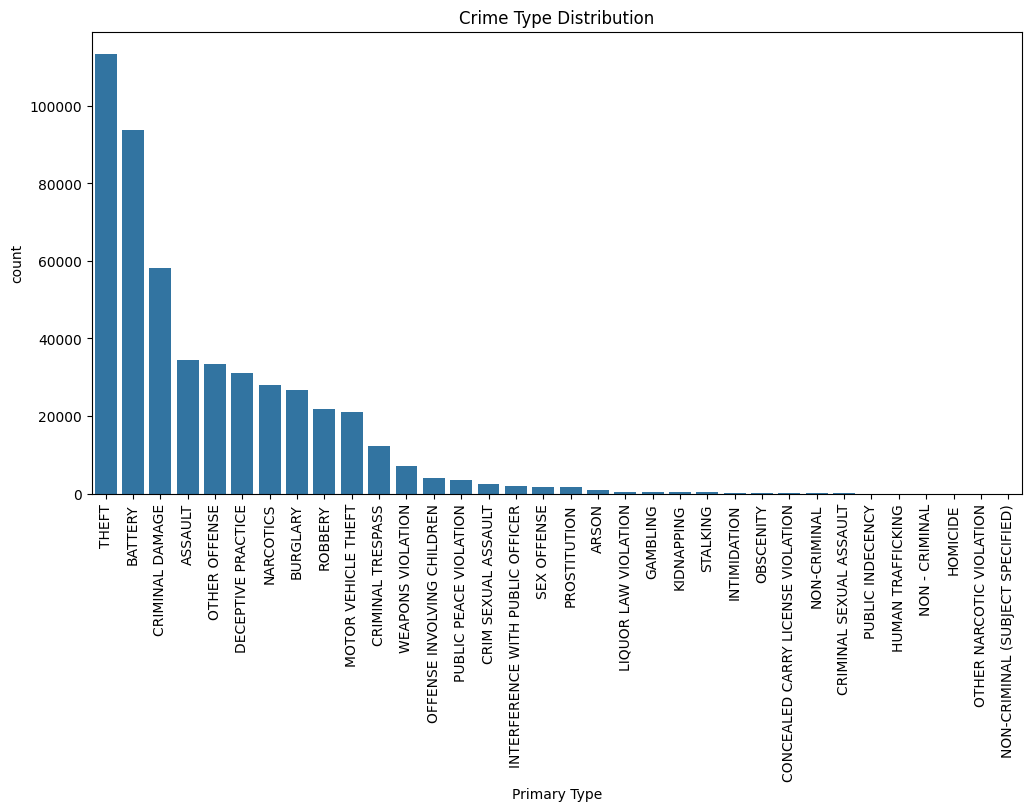

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(x='Primary Type', data=dataset,
              order=dataset['Primary Type'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Crime Type Distribution")
plt.show()  # We can see we have 10+ classes with class inbalance and many rare classes that affect could negativly imbact our model

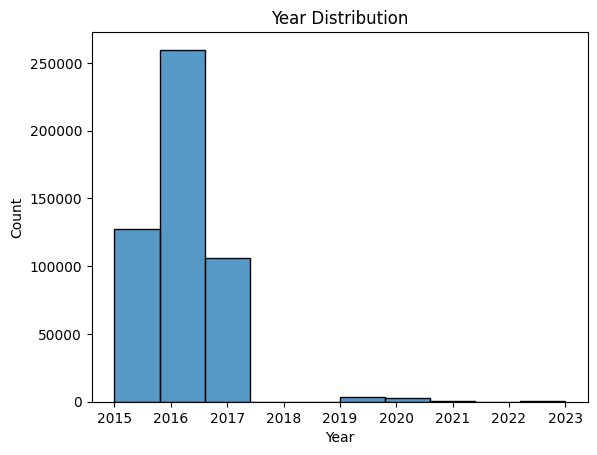

In [25]:
sns.histplot(dataset['Year'], bins=10)
plt.title("Year Distribution")
plt.show() # most of this data is from 2016 as ca be seen

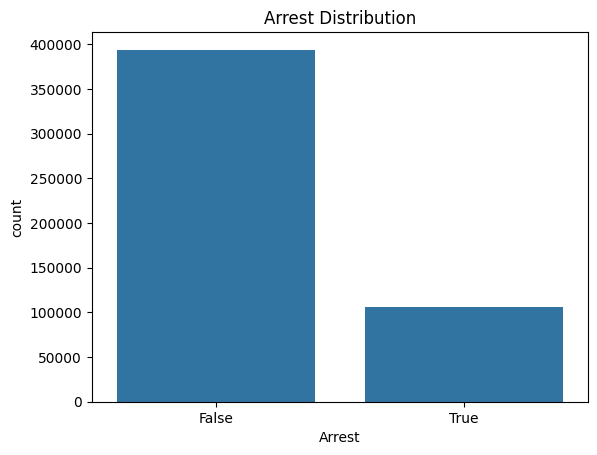

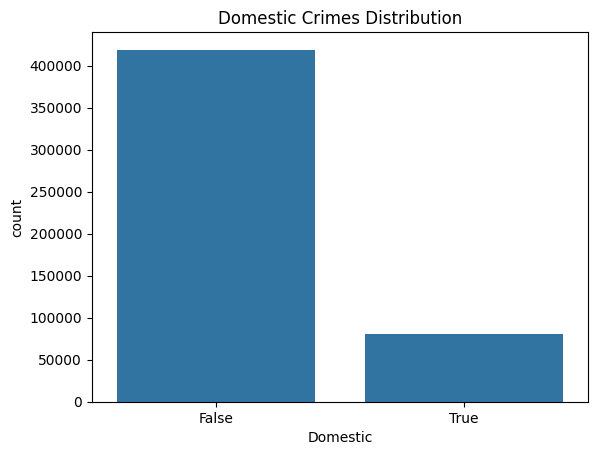

In [26]:
sns.countplot(x='Arrest', data=dataset)
plt.title("Arrest Distribution")
plt.show()

sns.countplot(x='Domestic', data=dataset)
plt.title("Domestic Crimes Distribution")
plt.show()

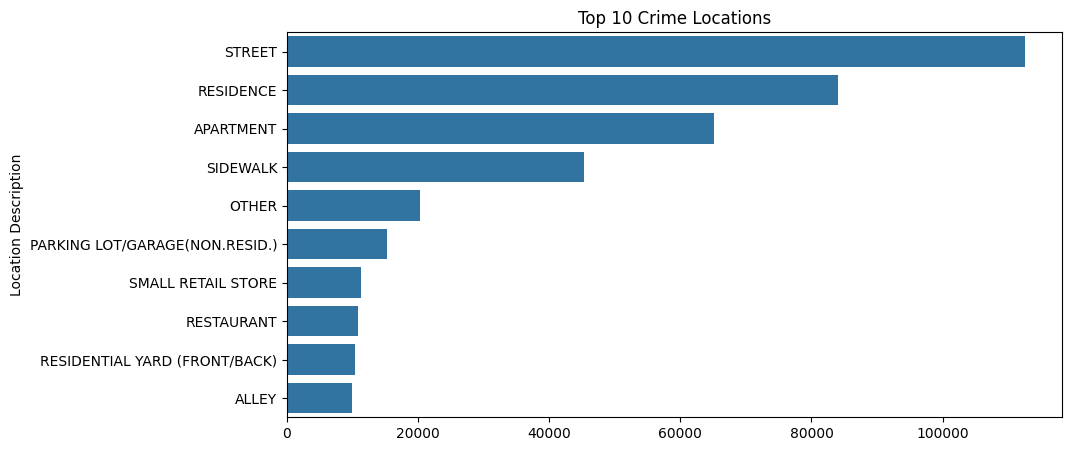

In [27]:
top_locations = dataset['Location Description'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Crime Locations")
plt.show()

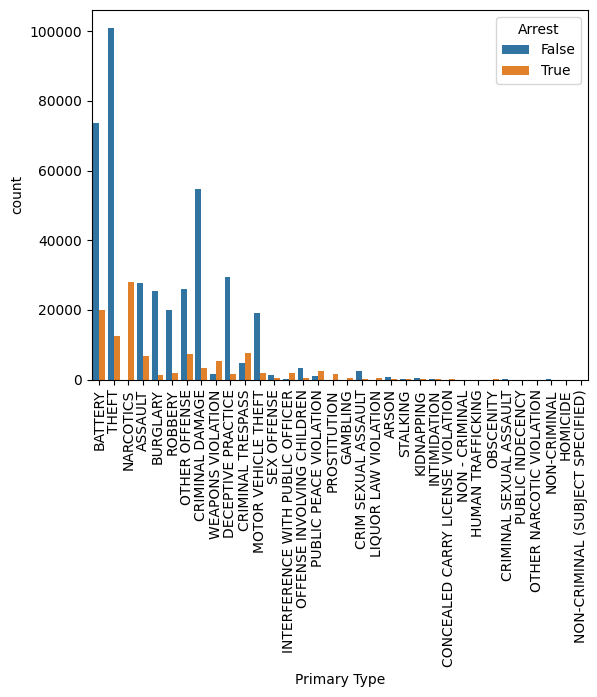

In [29]:
sns.countplot(x='Primary Type', hue='Arrest', data=dataset)
plt.xticks(rotation=90)
plt.show()

###correlation

In [87]:
import numpy as np

#Correlation
corr_matrix = dataset.corr(numeric_only=True)

#removing self-correlation
np.fill_diagonal(corr_matrix.values, 0)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# Step 5: get top values
top_positive = corr_pairs.sort_values(ascending=False).head(10)
top_negative = corr_pairs.sort_values().head(10)

print("Top Positive:\n", top_positive)
print("\nTop Negative:\n", top_negative)

Top Positive:
 Latitude   Y Coordinate    0.999995
Longitude  X Coordinate    0.999920
Beat       District        0.999614
ID         Year            0.931570
District   Ward            0.670637
Beat       Ward            0.669399
Latitude   Ward            0.655579
Ward       Y Coordinate    0.655245
District   Latitude        0.629207
           Y Coordinate    0.628368
dtype: float64

Top Negative:
 Community Area  Y Coordinate   -0.778085
                Latitude       -0.777370
Latitude        X Coordinate   -0.555233
District        X Coordinate   -0.554941
Beat            X Coordinate   -0.554054
X Coordinate    Y Coordinate   -0.552494
District        Longitude      -0.550059
Beat            Longitude      -0.549184
Latitude        Longitude      -0.544742
Longitude       Y Coordinate   -0.541980
dtype: float64


### PREPROCACING

In [89]:


dataset = dataset[dataset['Year'] >= 2015] # taking only 2015 and higher
dataset = dataset.dropna()



dataset = dataset[['Year', 'District', 'Primary Type', 'Arrest', 'Domestic',
                   'Location Description', 'Beat']] # taking only the neccasary information and useful features to reduce complexity + noise


dataset = dataset.dropna() # dropping missing values

# encoding catogorial features
dataset['Arrest'] = dataset['Arrest'].astype(str).str.lower().map({'true': 1, 'false': 0})
dataset['Domestic'] = dataset['Domestic'].astype(str).str.lower().map({'true': 1, 'false': 0})
dataset = pd.get_dummies(dataset, columns=['Location Description'])

le = LabelEncoder()
dataset['Primary Type'] = le.fit_transform(dataset['Primary Type'])
class_names = le.classes_






dataset.to_csv("cleaned_dataset.csv", index=False)

dataset.head()

,Year,District,Primary Type,Arrest,Domestic,Beat,Location Description_ABANDONED BUILDING,Location Description_AIRCRAFT,Location Description_AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA,Location Description_AIRPORT BUILDING NON-TERMINAL - SECURE AREA,...,Location Description_VACANT LOT / LAND,Location Description_VACANT LOT/LAND,Location Description_VEHICLE - COMMERCIAL,Location Description_VEHICLE - DELIVERY TRUCK,Location Description_VEHICLE - OTHER RIDE SERVICE,"Location Description_VEHICLE - OTHER RIDE SHARE SERVICE (E.G., UBER, LYFT)","Location Description_VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)",Location Description_VEHICLE NON-COMMERCIAL,Location Description_VEHICLE-COMMERCIAL,Location Description_WAREHOUSE
0,2015,9.0,2,0,1,924,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,15.0,32,0,0,1511,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2015,14.0,18,1,0,1412,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2015,15.0,1,0,1,1522,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2015,6.0,3,0,0,614,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [90]:
import numpy as np

#Correlation
corr_matrix = dataset.corr(numeric_only=True)

#removing self-correlation
np.fill_diagonal(corr_matrix.values, 0)
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# Step 5: get top values
top_positive = corr_pairs.sort_values(ascending=False).head(10)
top_negative = corr_pairs.sort_values().head(10)

print("Top Positive:\n", top_positive)
print("\nTop Negative:\n", top_negative)

Top Positive:
 Beat                                                         District                                 0.999614
Domestic                                                     Location Description_APARTMENT           0.276599
                                                             Location Description_RESIDENCE           0.209293
Arrest                                                       Location Description_SIDEWALK            0.132395
Location Description_DEPARTMENT STORE                        Primary Type                             0.118273
Location Description_STREET                                  Primary Type                             0.101313
Arrest                                                       Location Description_DEPARTMENT STORE    0.095247
Location Description_SMALL RETAIL STORE                      Primary Type                             0.091106
Location Description_GROCERY FOOD STORE                      Primary Type                        

In [6]:
X = dataset.drop('Primary Type', axis=1)
y = dataset['Primary Type']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.naive_bayes import GaussianNB #Gaussian Naive Bayes because our data is numeric

model = GaussianNB()

In [11]:
model.fit(X_train, y_train) # training

y_pred = model.predict(X_test)# predictions



In [12]:
# Evalations
from sklearn.metrics import accuracy_score, classification_report
predicted_labels = le.inverse_transform(y_pred)
actual_labels = le.inverse_transform(y_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.03153
              precision    recall  f1-score   support

           0       0.00      0.01      0.00       185
           1       0.00      0.00      0.00      6881
           2       0.00      0.00      0.00     18585
           3       0.42      0.20      0.27      5303
           4       0.01      0.32      0.01        22
           5       0.03      0.02      0.02       511
           6       0.20      0.00      0.01     11590
           7       0.00      0.17      0.00         6
           8       0.19      0.03      0.05      2445
           9       0.48      0.15      0.23      6306
          10       0.00      0.10      0.01        71
          11       0.00      1.00      0.00         2
          12       0.00      0.50      0.00         2
          13       0.00      0.00      0.00       409
          14       0.00      0.02      0.00        46
          15       0.00      0.03      0.00        75
          16       0.05      0.56      0.09        94
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [13]:
predicted_labels = le.inverse_transform(y_pred)
actual_labels = le.inverse_transform(y_test)

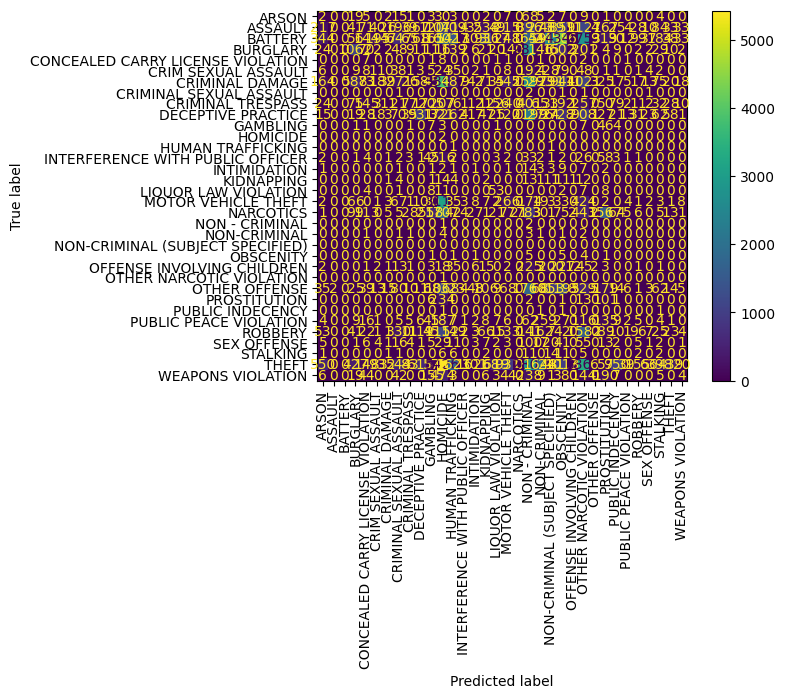

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.show() # too crowded so we will show it useing a diffrent way

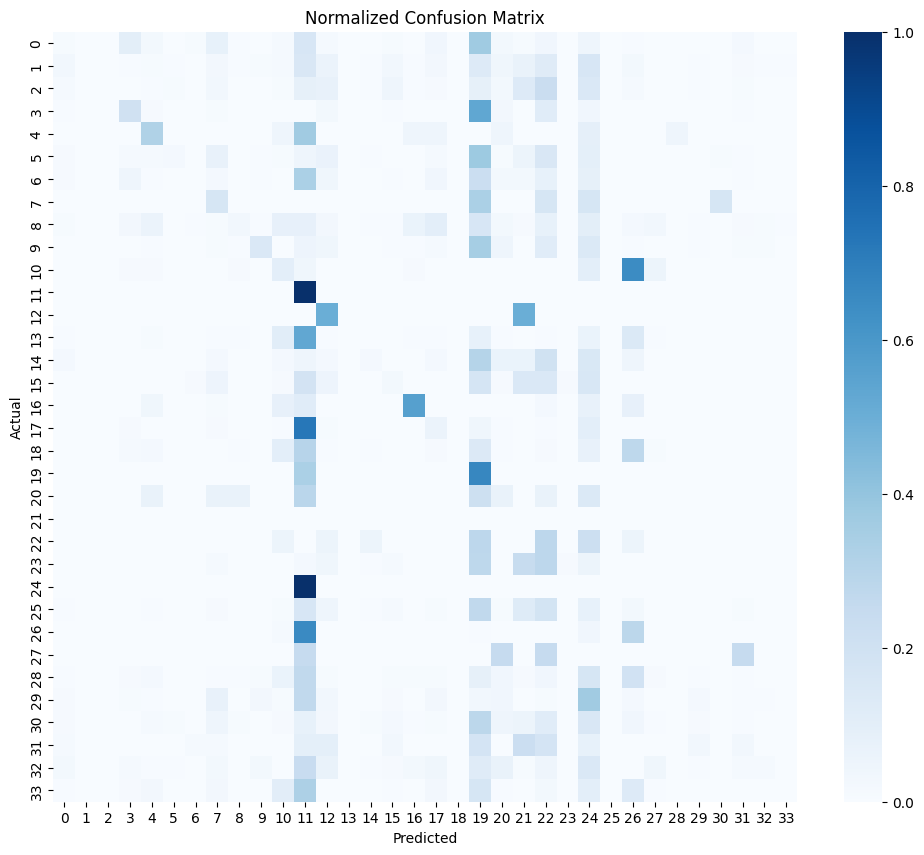

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap='Blues')
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Reducing comatatinal and sing what it does

In [74]:
dataset_reduced = dataset[['Year', 'District', 'Primary Type', 'Arrest',
                   'Domestic', 'Location Description', 'Beat']]

In [75]:
top_classes = dataset_reduced['Primary Type'].value_counts().nlargest(10).index
dataset_reduced = dataset_reduced[dataset_reduced['Primary Type'].isin(top_classes)]

In [77]:
#  clean text
dataset_reduced['Location Description'] = dataset_reduced['Location Description'].str.upper()

top_locations = dataset_reduced['Location Description'].value_counts().nlargest(15).index

dataset_reduced['Location Description'] = dataset_reduced['Location Description'].apply(
    lambda x: x if x in top_locations else 'OTHER'
)

# encode
dataset_reduced = pd.get_dummies(dataset_reduced, columns=['Location Description'])

# check
print(dataset_reduced.filter(like='Location Description').columns)

Index(['Location Description_ALLEY', 'Location Description_APARTMENT',
       'Location Description_DEPARTMENT STORE', 'Location Description_OTHER',
       'Location Description_PARKING LOT/GARAGE(NON.RESID.)',
       'Location Description_RESIDENCE',
       'Location Description_RESIDENCE PORCH/HALLWAY',
       'Location Description_RESIDENCE-GARAGE',
       'Location Description_RESIDENTIAL YARD (FRONT/BACK)',
       'Location Description_RESTAURANT',
       'Location Description_SCHOOL, PUBLIC, BUILDING',
       'Location Description_SIDEWALK',
       'Location Description_SMALL RETAIL STORE',
       'Location Description_STREET',
       'Location Description_VEHICLE NON-COMMERCIAL'],
      dtype='object')


In [78]:
print(dataset_reduced.dtypes)

Year                                                     int64
District                                               float64
Primary Type                                            object
Arrest                                                    bool
Domestic                                                  bool
Beat                                                     int64
Location Description_ALLEY                                bool
Location Description_APARTMENT                            bool
Location Description_DEPARTMENT STORE                     bool
Location Description_OTHER                                bool
Location Description_PARKING LOT/GARAGE(NON.RESID.)       bool
Location Description_RESIDENCE                            bool
Location Description_RESIDENCE PORCH/HALLWAY              bool
Location Description_RESIDENCE-GARAGE                     bool
Location Description_RESIDENTIAL YARD (FRONT/BACK)        bool
Location Description_RESTAURANT                        

In [79]:
from sklearn.model_selection import train_test_split

X = dataset_reduced.drop('Primary Type', axis=1)
y = dataset_reduced['Primary Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for class balance
)

In [80]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

In [81]:
X_train_resampled.select_dtypes(include='object').head()

""
0
1
2
3
4


In [82]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [83]:
y_pred = model.predict(X_test)

In [84]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.21927916815442378


In [85]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

                     precision    recall  f1-score   support

            ASSAULT       0.18      0.07      0.10      6888
            BATTERY       0.71      0.05      0.09     18766
           BURGLARY       0.23      0.79      0.36      5354
    CRIMINAL DAMAGE       0.14      0.00      0.01     11619
 DECEPTIVE PRACTICE       0.15      0.43      0.23      6232
MOTOR VEHICLE THEFT       0.15      0.83      0.25      4227
          NARCOTICS       0.45      0.54      0.49      5611
      OTHER OFFENSE       0.14      0.30      0.19      6692
            ROBBERY       0.30      0.40      0.34      4338
              THEFT       0.73      0.07      0.13     22694

           accuracy                           0.22     92421
          macro avg       0.32      0.35      0.22     92421
       weighted avg       0.44      0.22      0.17     92421

